In [1]:
import numpy as np
import os

# Load the unified peaks dataset
peaks_data = np.load('unified_range_matched_peaks_F1-F12.npz', allow_pickle=True)
print("Keys:", list(peaks_data.keys()))
for k in peaks_data.keys():
 arr = peaks_data[k]
 print(f"{k}: shape={arr.shape if hasattr(arr,'shape') else type(arr)}, dtype={arr.dtype if hasattr(arr,'dtype') else ''}")


FileNotFoundError: [Errno 2] No such file or directory: 'unified_range_matched_peaks_F1-F12.npz'

In [2]:
import subprocess
result = subprocess.run(['find', '/workspace', '-name', '*.npz', '-type', 'f'], capture_output=True, text=True)
print(result.stdout)


In [3]:
result = subprocess.run(['ls', '-la', '/workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/'], capture_output=True, text=True)
print(result.stdout)
print("STDERR:", result.stderr)


total 60568
drwxrwsr-x 5 root jupytergroup 4096 May 9 11:50 .
drwxr-xr-x 5 root root 4096 May 9 11:50 ..
drwxrwsr-x 5 root jupytergroup 4096 May 9 11:50 .config
-rw-rw-r-- 1 kerneluser jupytergroup 0 May 9 11:50 .kernel_llm_logs_1.txt
drwxrwsr-x 2 root jupytergroup 4096 May 9 11:50 .prompts
-rw-r--r-- 1 root jupytergroup 100702 May 9 11:50 v6 — Binding Context Document.pdf
-rw-r--r-- 1 root jupytergroup 136 May 9 11:50 N.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F1.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F10.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F11.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F12.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F2.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F4.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F5m.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F5p.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F6.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F7.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F9.npy
-rw-r

In [4]:
result = subprocess.run(['ls', '-la', '/workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/'], capture_output=True, text=True)
# Print only files we need
for line in result.stdout.split('\n'):
 if any(x in line for x in ['amp', 'F9', 'F15', 'chi5', 'lam', 'tau', 'a_n', '.npy', '.npz']):
 print(line)


-rw-r--r-- 1 root jupytergroup 136 May 9 11:50 N.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F1.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F10.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F11.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F12.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F2.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F4.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F5m.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F5p.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F6.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F7.npy
-rw-r--r-- 1 root root 25728 May 9 11:50 Sk_F9.npy
-rw-r--r-- 1 root jupytergroup 7238129 May 9 11:50 a_n_imag.npy
-rw-r--r-- 1 root jupytergroup 7238213 May 9 11:50 a_n_real.npy
-rw-r--r-- 1 root root 1728 May 9 11:50 amp_peaks_F1.npy
-rw-r--r-- 1 root root 1728 May 9 11:50 amp_peaks_F10.npy
-rw-r--r-- 1 root root 1728 May 9 11:50 amp_peaks_F11.npy
-rw-r--r-- 1 root root 1728 May 9 11:50 amp_peaks_F12.npy
-rw-r--r-- 1 root root

In [5]:
os.chdir('/workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/')

# Load the unified data as individual .npy files
N = np.load('N.npy')
function_names = np.load('function_names.npy')
k_range = np.load('k_range.npy')
t_min = np.load('t_min.npy')
t_max = np.load('t_max.npy')
n_peaks = np.load('n_peaks.npy')
kappa = np.load('kappa.npy')

print("N:", N)
print("function_names:", function_names)
print("k_range:", k_range)
print(f"t range: [{t_min}, {t_max}]")
print("n_peaks:", n_peaks)
print("kappa:", kappa)

# Load F9 specifics
Sk_F9 = np.load('Sk_F9.npy')
t_peaks_F9 = np.load('t_peaks_F9.npy')
amp_peaks_F9 = np.load('amp_peaks_F9.npy')
print("\nSk_F9 shape:", Sk_F9.shape, "dtype:", Sk_F9.dtype)
print("t_peaks_F9 shape:", t_peaks_F9.shape)
print("amp_peaks_F9 shape:", amp_peaks_F9.shape)


N: 1000000
function_names: ['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
k_range: [0 1 2 3 4 5 6 7]
t range: [10000.0, 20000.0]
n_peaks: 200
kappa: 0.28407904384041227

Sk_F9 shape: (200, 8) dtype: complex128
t_peaks_F9 shape: (200,)
amp_peaks_F9 shape: (200,)


In [6]:
# Load F15 coefficients
a_n_real = np.load('a_n_real.npy', allow_pickle=True)
a_n_imag = np.load('a_n_imag.npy', allow_pickle=True)
lam = np.load('lam.npy')
tau = np.load('tau.npy', allow_pickle=True)

print("a_n_real shape:", a_n_real.shape, "dtype:", a_n_real.dtype)
print("a_n_imag shape:", a_n_imag.shape, "dtype:", a_n_imag.dtype)
print("lam shape:", lam.shape, "dtype:", lam.dtype)
print("tau shape:", tau.shape, "dtype:", tau.dtype)
print("\nFirst 10 lam:", lam[:10])
print("First 10 tau:", tau[:10])


a_n_real shape: (1000001,) dtype: object
a_n_imag shape: (1000001,) dtype: object
lam shape: (1000001,) dtype: complex128
tau shape: (1000001,) dtype: object

First 10 lam: [ 0. +0.j 1. +0.j 0. -0.53033009j
 0. -0.59873361j 0.71875 +0.j 0. +0.j
 -0.31752645+0.j 0. -0.3765477j 0. -0.91150484j
 0.64151806+0.j ]
First 10 tau: [0 1 -24 252 -1472 4830 -6048 -16744 84480 -113643]


In [7]:
# Read the binding context to understand definitions of S_k and M_jk
import subprocess
result = subprocess.run(['ls', '/workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/'], capture_output=True, text=True)
print([f for f in result.stdout.split() if 'pdf' in f.lower() or 'md' in f.lower()])


['Document.pdf']


In [8]:
# Check additional parameters
min_peak_gap_t = np.load('min_peak_gap_t.npy')
print("min_peak_gap_t:", min_peak_gap_t)
print("kappa:", kappa)

# Check chi5 file
import os
files = os.listdir('.')
print([f for f in files if 'chi' in f.lower()])
print([f for f in files if f.endswith('.npy')][:50])


min_peak_gap_t: 2.0
kappa: 0.28407904384041227
['chi5.npy']
['k_range.npy', 't_peaks_F12.npy', 'Sk_F5m.npy', 'Sk_F9.npy', 'min_peak_gap_t.npy', 't_peaks_F5p.npy', 'kappa.npy', 't_peaks_F4.npy', 'amp_peaks_F12.npy', 'amp_peaks_F9.npy', 'Sk_F2.npy', 'amp_peaks_F5m.npy', 't_peaks_F11.npy', 't_peaks_F2.npy', 'lam.npy', 'description.npy', 'Sk_F11.npy', 'a_n_imag.npy', 't_peaks_F10.npy', 'amp_peaks_F6.npy', 'Sk_F5p.npy', 't_max.npy', 't_min.npy', 'Sk_F12.npy', 'amp_peaks_F2.npy', 'epsilon_F5.npy', 'chi5.npy', 't_peaks_F5m.npy', 't_peaks_F6.npy', 'Sk_F4.npy', 'Sk_F7.npy', 'Sk_F1.npy', 'n_peaks.npy', 'amp_peaks_F11.npy', 'amp_peaks_F4.npy', 'amp_peaks_F10.npy', 'amp_peaks_F7.npy', 'Sk_F10.npy', 't_peaks_F7.npy', 't_peaks_F1.npy', 'N.npy', 'a_n_real.npy', 't_peaks_F9.npy', 'Sk_F6.npy', 'tau.npy', 'amp_peaks_F1.npy', 'amp_peaks_F5p.npy', 'function_names.npy']


In [9]:
chi5 = np.load('chi5.npy')
print("chi5 shape:", chi5.shape, "dtype:", chi5.dtype)
print("chi5[0:6]:", chi5[0:6])
# Should be [0,1,i,-i,-1] periodic
# Note from spec: chi5(0,1,2,3,4)=(0,1,i,-i,-1)


chi5 shape: (1000001,) dtype: complex128
chi5[0:6]: [ 0.+0.j 1.+0.j 0.+1.j -0.-1.j -1.+0.j 0.+0.j]


In [10]:
# Great. Now let's set up the analysis plan.
# 
# F9: lambda_F9(n) = tau(n)/n^(11/2) (analytically normalized)
# F15: lambda_F15(n) = a_n / n^(11/2) where a_n = tau(n)*chi5(n)
# 
# Verify: lam (loaded above) should be lambda_F15
# Also need lambda_F9 = tau / n^(11/2)
#
# Plan:
# 1. Construct lambda_F9 (real values).
# 2. Find peaks for F15 in [t_min,t_max] using finufft + lam (F15 already normalized).
# 3. Compute S_k(F15) at those peaks via Kahan summation, stratified by ω(n).
# 4. Compute M_jk(F15) = Cov[log|S_j|, log|S_k|] over 200 peaks (8x8).
# 5. Use Sk_F9 already loaded -> M_jk(F9).
# 6. Construct ablated F9: at the F9 peaks, recompute S_k using twisted coefficients lam_F9(n)*chi5(n) = lam_F15(n).
# => This is essentially what F15's S_k(t) at F9 peaks would be.
# Actually the prompt says "re-weight terms where chi5(n) != 1". A natural model:
# lam_F9_ablated(n) = lam_F9(n) * chi5(n) (= lam_F15(n))
# 7. Compute M_jk(F9_ablated) and Δ_predicted = M(F9_ablated) - M(F9).
# 8. Compare to Δ_empirical = M(F15) - M(F9).
# 9. Report cosine similarity and Pearson correlation between vectorized 8x8 matrices (excluding leak channels).

# Validate lam = tau * chi5 / n^(11/2)
n_idx = np.arange(1, 11)
expected_lam = np.array([float(tau[n]) for n in n_idx]) * chi5[1:11] / (n_idx**5.5)
print("Expected:", expected_lam[:5])
print("Stored: ", lam[1:6])
print("Match:", np.allclose(lam[1:11], expected_lam))


Expected: [ 1. +0.j -0. -0.53033009j 0. -0.59873361j
 0.71875-0.j 0. +0.j ]
Stored: [1. +0.j 0. -0.53033009j 0. -0.59873361j
 0.71875+0.j 0. +0.j ]
Match: True


In [11]:
# Now construct lambda_F9 = tau / n^(11/2)
N_total = 1_000_000
n_arr = np.arange(0, N_total + 1)
# tau is object array (Python ints) - need to convert
# For n=0, tau=0; for n=1, tau=1
# tau[n] up to 4e33 - cannot fit float64 even after dividing because n^5.5 grows but at n=10^6, n^5.5 = 10^33
# Actually a_n / n^(11/2) ~ O(1) by Deligne. Let's compute in higher precision via Python ints + division at the end.

# Use chi5 to back out lam_F9: lam_F15 = lam_F9 * chi5
# At positions where chi5 != 0: lam_F9 = lam_F15 / chi5
# At positions where chi5 == 0 (n divisible by 5): lam_F9 != 0 in general but is killed by chi5.
# So we can't recover lam_F9 from lam alone. Must compute from tau.

# Compute lam_F9[n] = tau[n] / n^(11/2). Tau values are large ints. Use Python float division on Python ints for accuracy.
import time
t0 = time.time()
lam_F9 = np.zeros(N_total + 1, dtype=np.float64)
for n in range(1, N_total + 1):
 lam_F9[n] = float(tau[n]) / (n ** 5.5)
print(f"Computed lam_F9 in {time.time()-t0:.1f}s")
print("lam_F9[1:10]:", lam_F9[1:10])
print("|lam_F9| max:", np.abs(lam_F9).max()) # should be <= ~ 2 by Deligne (sigma_0(n))


Computed lam_F9 in 0.3s
lam_F9[1:10]: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333 -0.31752645
 -0.3765477 0.91150484 -0.64151806]
|lam_F9| max: 5.382369221754193


In [12]:
# Note signs differ from lam_F15 because chi5 introduces complex factors.
# Sanity: lam_F9[2] = -0.530..., lam_F15[2] = -0.530...i (chi5(2)=i, so -0.53*i = -0.53i). Correct.

# Verify F9 lam from existing ground truth - compare to existing Sk_F9 below.

# Compute omega(n) for n in [1, N_total]
import time
t0 = time.time()
# Use sieve
omega = np.zeros(N_total + 1, dtype=np.int8)
for p in range(2, N_total + 1):
 if omega[p] == 0: # p is prime (we set omega for primes first - actually we need different approach)
 pass

# Smallest prime factor sieve approach for omega
spf = np.zeros(N_total + 1, dtype=np.int32)
for i in range(2, N_total + 1):
 if spf[i] == 0: # prime
 for j in range(i, N_total + 1, i):
 if spf[j] == 0:
 spf[j] = i

print(f"SPF sieve in {time.time()-t0:.1f}s")


SPF sieve in 0.7s


In [13]:
# Now compute omega(n)
t0 = time.time()
omega = np.zeros(N_total + 1, dtype=np.int8)
for n in range(2, N_total + 1):
 m = n
 last_p = 0
 cnt = 0
 while m > 1:
 p = spf[m]
 if p != last_p:
 cnt += 1
 last_p = p
 m //= p
 omega[n] = cnt
print(f"omega computed in {time.time()-t0:.1f}s")
print("Max omega:", omega.max())
print("Distribution of omega for n in [2,N]:")
for k in range(0, 9):
 print(f" omega={k}: {(omega == k).sum()}")


omega computed in 1.1s
Max omega: 7
Distribution of omega for n in [2,N]:
 omega=0: 2
 omega=1: 78734
 omega=2: 288726
 omega=3: 379720
 omega=4: 208034
 omega=5: 42492
 omega=6: 2285
 omega=7: 8
 omega=8: 0


In [14]:
# Note: max omega is 7. Set omega[1] = 0 (k=0 stratum has only n=1).
# Already 0 by default.
print("omega[1]:", omega[1])

# Now: k=0 contains only n=1 (omega=0).
# For each k in 0..7, we need the indices.
strata_idx = [np.where(omega == k)[0] for k in range(8)]
for k in range(8):
 idx = strata_idx[k]
 print(f"k={k}: {len(idx)} indices, first few: {idx[:5]}")


omega[1]: 0
k=0: 2 indices, first few: [0 1]
k=1: 78734 indices, first few: [2 3 4 5 7]
k=2: 288726 indices, first few: [ 6 10 12 14 15]
k=3: 379720 indices, first few: [30 42 60 66 70]
k=4: 208034 indices, first few: [210 330 390 420 462]
k=5: 42492 indices, first few: [2310 2730 3570 3990 4290]
k=6: 2285 indices, first few: [30030 39270 43890 46410 51870]
k=7: 8 indices, first few: [510510 570570 690690 746130 870870]


In [15]:
# For k=0 we want only n=1 (drop n=0). And for k>=1 we drop n=0/1 anyway since omega is 0 only for 0,1.
# Actually omega[0]=0 too. But n=0 isn't a Dirichlet index. Let's exclude n=0.

# Build masks: for each k, indices of n in [1, N] with omega(n) == k (for k=0 only n=1).
strata_idx = []
for k in range(8):
 idx = np.where(omega == k)[0]
 idx = idx[idx >= 1] # exclude n=0
 strata_idx.append(idx)
for k in range(8):
 print(f"k={k}: {len(strata_idx[k])} indices")


k=0: 1 indices
k=1: 78734 indices
k=2: 288726 indices
k=3: 379720 indices
k=4: 208034 indices
k=5: 42492 indices
k=6: 2285 indices
k=7: 8 indices


In [16]:
# For F15, since chi5(n)=0 when 5|n, all those terms are killed. 
# Let's see how many F15 terms in each stratum are actually nonzero
for k in range(8):
 idx = strata_idx[k]
 nz = (chi5[idx] != 0).sum()
 print(f"k={k}: {len(idx)} terms, nonzero in F15: {nz}")


k=0: 1 terms, nonzero in F15: 1
k=1: 78734 terms, nonzero in F15: 78726
k=2: 288726 terms, nonzero in F15: 264895
k=3: 379720 terms, nonzero in F15: 304372
k=4: 208034 terms, nonzero in F15: 133364
k=5: 42492 terms, nonzero in F15: 18228
k=6: 2285 terms, nonzero in F15: 414
k=7: 8 terms, nonzero in F15: 0


In [17]:
# OK. So k=7 will be all zeros for F15 (mod-5 conductor effect noted in the spec).
# This is one of the documented data leaks.
#
# Now: I need to find F15 peaks first. Let me set up finufft to compute D_F15(t) on a fine t-grid.
# D(t) = sum_{n=1}^{N} lam(n) n^{-it}
# This is a type-3 NUFFT (nonuniform sources at log(n), targets t).
# Equivalently: D(t) = sum_n lam(n) * exp(-i*t*log(n)).

import finufft

t0 = time.time()
# n_grid for finufft - we need fine sampling. Min peak gap = 2 in t, range [1e4, 2e4].
# Range length = 1e4. Use grid spacing of e.g. 0.05 -> 200_000 t points. That's reasonable.
# Actually the "log" frequencies are log(n) for n=1..N. log(N) = ~13.8.
# T_range = t_max - t_min = 1e4. We need to sample finely enough to resolve oscillations of n^{-it} ~ exp(-i*t*log(n)).
# Highest frequency is log(N) = 13.8. So oscillation period in t is 2*pi/log(N) ~ 0.45.
# Sample at dt=0.05 -> 9 samples per period. Good.

dt = 0.05
t_grid = np.arange(t_min, t_max, dt)
print(f"t_grid size: {len(t_grid)}")

# We use finufft type 3: takes nonuniform sources x_j (here x_j = log(n) for n in 1..N), strengths c_j (lam(n)),
# nonuniform targets s_k (here s_k = t in t_grid), evaluates F(s_k) = sum_j c_j exp(i s_k x_j).
# We want sum_n lam(n) exp(-i t log(n)) = sum_n lam(n) exp(i (-t) log(n)). 
# So if we set s_k = -t_k and x_j = log(n), c_j = lam(n), finufft computes sum_j c_j exp(i s_k x_j) = sum_n lam(n) exp(-i t_k log(n)). Good.

n_vals = np.arange(1, N_total + 1)
log_n = np.log(n_vals).astype(np.float64)
strengths_F15 = lam[1:].astype(np.complex128)
print("Strengths shape:", strengths_F15.shape)


ModuleNotFoundError: No module named 'finufft'

In [18]:
import subprocess
r = subprocess.run(['pip', 'install', '-q', 'finufft'], capture_output=True, text=True)
print(r.stdout[-1000:])
print("STDERR:", r.stderr[-500:])



STDERR: 


In [19]:
import finufft
print(finufft.__version__)


2.5.1


In [20]:
import time
t0 = time.time()

dt = 0.05
t_grid = np.arange(t_min, t_max, dt)
n_grid = len(t_grid)
print(f"t_grid: {n_grid} points")

n_vals = np.arange(1, N_total + 1)
log_n = np.log(n_vals).astype(np.float64)

# finufft type 3: F(s_k) = sum_j c_j exp(i s_k x_j)
# We want D(t_k) = sum_n lam(n) exp(-i t_k log(n))
# So x_j = log(n_j), c_j = lam(n_j), s_k = -t_k
s_targets = -t_grid.astype(np.float64)
strengths_F15 = lam[1:].astype(np.complex128)

# Compute D_F15
D_F15 = finufft.nufft1d3(log_n, strengths_F15, s_targets, eps=1e-9, isign=1)
print(f"D_F15 computed in {time.time()-t0:.1f}s, shape={D_F15.shape}")
print(f"|D_F15| range: [{np.abs(D_F15).min():.3f}, {np.abs(D_F15).max():.3f}]")


t_grid: 200000 points
D_F15 computed in 0.1s, shape=(200000,)
|D_F15| range: [1.601, 2857.527]


In [21]:
# Hmm 0.1s seems too fast - let me verify by checking a small set with direct computation
# Pick t=15000. Compute D(15000) directly with first 1000 terms (just sanity check)

# Actually finufft can be that fast. Let's verify on a small N
t_test = np.array([15000.0])
N_small = 1000
strengths_small = lam[1:N_small+1].astype(np.complex128)
log_n_small = np.log(np.arange(1, N_small+1)).astype(np.float64)
D_small_finufft = finufft.nufft1d3(log_n_small, strengths_small, -t_test, eps=1e-12, isign=1)
# Direct
D_small_direct = np.sum(strengths_small * np.exp(-1j * 15000.0 * log_n_small))
print(f"finufft: {D_small_finufft[0]}")
print(f"direct: {D_small_direct}")
print(f"|diff|: {abs(D_small_finufft[0] - D_small_direct):.2e}")


finufft: (8.459132451430603-5.56620945763573j)
direct: (8.45913245142935-5.566209457635313j)
|diff|: 1.32e-12


In [22]:
# Good, finufft matches direct. Now find peaks for F15.
from scipy.signal import find_peaks

amp_F15 = np.abs(D_F15)
# Find local maxima with min separation. min_peak_gap_t = 2.0, dt = 0.05 -> distance = 40 samples
distance_samples = int(min_peak_gap_t / dt)
print("distance_samples:", distance_samples)

peaks_idx, _ = find_peaks(amp_F15, distance=distance_samples)
print(f"Found {len(peaks_idx)} candidate peaks")

# Sort by amplitude and select top 200
top_idx = peaks_idx[np.argsort(amp_F15[peaks_idx])[::-1][:200]]
top_idx = np.sort(top_idx) # sort by t
t_peaks_F15_initial = t_grid[top_idx]
amp_peaks_F15_initial = amp_F15[top_idx]
print(f"Top 200 peak amplitudes: min={amp_peaks_F15_initial.min():.2f}, max={amp_peaks_F15_initial.max():.2f}")
print("First 5 peak t:", t_peaks_F15_initial[:5])


distance_samples: 40
Found 2912 candidate peaks
Top 200 peak amplitudes: min=1402.63, max=2857.53
First 5 peak t: [10043.35 10093.95 10143.35 10151.55 10160.95]


In [23]:
# Refine peak locations: use a finer search around each peak using direct evaluation 
# (to get accurate t_peak rather than the nearest grid point)
# Actually since we just need M_jk on the peaks, and Sk are computed at the peak t, accuracy of t_peak matters
# but since the difference in t is at most dt/2 = 0.025, this is small. However for cleaner results
# let's do a fine local refinement using golden section.

# Simpler: use a finer t-grid in a window around each peak to find the true max.
def refine_peak(t0_initial, n_vals, log_n, strengths, dt_fine=0.001, window=0.1):
 t_local = np.arange(t0_initial - window, t0_initial + window, dt_fine)
 s_loc = -t_local
 D_loc = finufft.nufft1d3(log_n, strengths, s_loc, eps=1e-10, isign=1)
 amp_loc = np.abs(D_loc)
 j = np.argmax(amp_loc)
 return t_local[j], amp_loc[j]

t_peaks_F15 = np.zeros(200)
amp_peaks_F15 = np.zeros(200)
t0 = time.time()
for i, t_init in enumerate(t_peaks_F15_initial):
 t_peaks_F15[i], amp_peaks_F15[i] = refine_peak(t_init, n_vals, log_n, strengths_F15)
print(f"Refined in {time.time()-t0:.1f}s")
print("First 5 refined peaks:", t_peaks_F15[:5])
print("Refined amps min:", amp_peaks_F15.min(), "max:", amp_peaks_F15.max())


Refined in 8.8s
First 5 refined peaks: [10043.335 10093.961 10143.343 10151.566 10160.929]
Refined amps min: 1403.266469754347 max: 2860.5122556991305


In [24]:
# Now check that these are the top 200 by amplitude after refinement.
# After refinement, ranking might change slightly; verify min separation still satisfied.
gaps = np.diff(np.sort(t_peaks_F15))
print("Min gap after refinement:", gaps.min())
print("All gaps >= 2.0?", (gaps >= 2.0).all())

# Reorder by amplitude to ensure top 200
order = np.argsort(amp_peaks_F15)[::-1]
print("Sorted amplitudes top 5:", amp_peaks_F15[order][:5])
print("Sorted amplitudes bottom 5:", amp_peaks_F15[order][-5:])


Min gap after refinement: 2.2269999999625725
All gaps >= 2.0? True
Sorted amplitudes top 5: [2860.5122557 2819.77429425 2705.8614223 2699.44221862 2692.16437832]
Sorted amplitudes bottom 5: [1408.87131654 1406.67408629 1404.9155217 1404.01707134 1403.26646975]


In [25]:
# Good. Now compute S_k(F15) at these 200 peaks using Kahan compensated summation.
# S_k(t) = sum_{n: omega(n)=k} lam(n) * n^{-it}
# 
# Implement Kahan summation in Numba.

from numba import njit, prange

@njit(parallel=True, fastmath=False)
def compute_Sk_kahan(t_peaks, lam_real, lam_imag, log_n_arr, omega_arr, K):
 """Compute S_k(t_p) for each peak and stratum k=0..K-1.
 t_peaks: (P,) array of peak t-values
 lam_real, lam_imag: (N+1,) arrays of complex coefficients (lam[0] ignored)
 log_n_arr: (N+1,) array, log_n_arr[n] = log(n) for n>=1
 omega_arr: (N+1,) int array
 K: number of strata
 Returns S: (P, K) complex array
 """
 P = t_peaks.shape[0]
 N = log_n_arr.shape[0] - 1 # since indices go 0..N
 Sr = np.zeros((P, K), dtype=np.float64)
 Si = np.zeros((P, K), dtype=np.float64)
 for p in prange(P):
 t = t_peaks[p]
 # Per-peak Kahan accumulators
 sumR = np.zeros(K)
 cR = np.zeros(K)
 sumI = np.zeros(K)
 cI = np.zeros(K)
 for n in range(1, N + 1):
 k = omega_arr[n]
 if k >= K:
 continue
 # n^{-it} = exp(-i*t*log(n)) = cos(-t*ln) + i sin(-t*ln) = cos(t*ln) - i sin(t*ln)
 phase = -t * log_n_arr[n]
 cph = np.cos(phase)
 sph = np.sin(phase)
 lr = lam_real[n]
 li = lam_imag[n]
 # term = (lr + i*li) * (cph + i*sph) = (lr*cph - li*sph) + i*(lr*sph + li*cph)
 tr = lr * cph - li * sph
 ti = lr * sph + li * cph
 # Kahan add for real
 yR = tr - cR[k]
 tR = sumR[k] + yR
 cR[k] = (tR - sumR[k]) - yR
 sumR[k] = tR
 # Kahan add for imag
 yI = ti - cI[k]
 tI = sumI[k] + yI
 cI[k] = (tI - sumI[k]) - yI
 sumI[k] = tI
 for k in range(K):
 Sr[p, k] = sumR[k]
 Si[p, k] = sumI[k]
 return Sr, Si

# Prepare arrays
lam_real = np.real(lam).astype(np.float64)
lam_imag = np.imag(lam).astype(np.float64)
log_n_full = np.zeros(N_total + 1, dtype=np.float64)
log_n_full[1:] = np.log(np.arange(1, N_total + 1))
omega_arr = omega.astype(np.int32)

print("Compiling and running for F15...")
t0 = time.time()
Sr_F15, Si_F15 = compute_Sk_kahan(t_peaks_F15.astype(np.float64), lam_real, lam_imag, log_n_full, omega_arr, 8)
print(f"Done in {time.time()-t0:.1f}s")
Sk_F15 = Sr_F15 + 1j * Si_F15
print("Sk_F15 shape:", Sk_F15.shape)
print("Sk_F15[0]:", Sk_F15[0])


Compiling and running for F15...


Done in 3.3s
Sk_F15 shape: (200, 8)
Sk_F15[0]: [ 1. +0.j 44.82513227+135.66274523j
 925.9144574 -582.43814037j -51.97724247-391.0360137j
 380.11209311-114.71900996j 55.09291513 -89.52321891j
 4.5602566 -1.74447231j 0. +0.j ]


In [26]:
# Excellent. S_0 = 1 (lam(1)=1), S_7 = 0 (mod 5 conductor). Confirms expected leaks.
# Verify: total |sum S_k| should equal |D| at peak
total_F15 = Sk_F15.sum(axis=1)
print("|D| at first peak:", amp_peaks_F15[0], "|sum Sk|:", np.abs(total_F15[0]))
print("|D| at peak 1:", amp_peaks_F15[1], "|sum Sk|:", np.abs(total_F15[1]))
# Verify match
print("All match:", np.allclose(np.abs(total_F15), amp_peaks_F15, rtol=1e-9, atol=1e-6))


|D| at first peak: 1714.009866474155 |sum Sk|: 1714.0098664769719
|D| at peak 1: 1541.2921385740196 |sum Sk|: 1541.2921385564593
All match: True


In [27]:
# Now compute the F9 ablated S_k:
# Ablation model: lam_F9_ablated(n) = lam_F9(n) * chi5(n).
# But this gives exactly lam_F15 (which we already have). So at F9's peaks, the ablated S_k
# = sum_{omega(n)=k} lam_F9(n)*chi5(n)*n^{-it_F9_peak} = sum_{omega(n)=k} lam_F15(n)*n^{-it_F9_peak}
# i.e., evaluate F15's stratified Dirichlet sum at F9's peak locations.

# Load F9 peak data and Sk
Sk_F9_loaded = np.load('Sk_F9.npy')
t_peaks_F9 = np.load('t_peaks_F9.npy')

print("Sk_F9 shape:", Sk_F9_loaded.shape)
print("First peak Sk:", Sk_F9_loaded[0])

# Verify Sk_F9 by recomputing with our pipeline (sanity check vs unified file)
print("\nRecomputing Sk_F9 to validate pipeline...")
t0 = time.time()
lam_F9_real = lam_F9.astype(np.float64)
lam_F9_imag = np.zeros_like(lam_F9_real)
Sr_F9_check, Si_F9_check = compute_Sk_kahan(t_peaks_F9.astype(np.float64), lam_F9_real, lam_F9_imag, log_n_full, omega_arr, 8)
Sk_F9_check = Sr_F9_check + 1j * Si_F9_check
print(f"Done in {time.time()-t0:.1f}s")
print("Max abs diff:", np.max(np.abs(Sk_F9_check - Sk_F9_loaded)))
print("Relative diff (max):", np.max(np.abs(Sk_F9_check - Sk_F9_loaded) / (np.abs(Sk_F9_loaded) + 1e-12)))


Sk_F9 shape: (200, 8)
First peak Sk: [ 1.00000000e+00+0.00000000e+00j 3.28947348e+00+7.11861088e-02j
 5.85859149e+00-4.75868709e-01j 6.05769354e+00-1.95510748e-01j
 2.29727088e+00-5.71620066e-01j 2.86203221e-01-1.71474982e-01j
 5.55255798e-03-1.28724059e-02j -1.15663360e-04+1.25915544e-04j]

Recomputing Sk_F9 to validate pipeline...


Done in 0.8s
Max abs diff: 1956.693243480457
Relative diff (max): 7490.759395624214


In [28]:
# Hmm. Big mismatch. Let's investigate.
# It seems Sk_F9 is NOT lam_F9 = tau / n^(11/2). Let me look at first peak.
# Sk_F9_loaded[0] = (1+0j, 3.29+0.07j, 5.86-0.48j, ...)
# Sk_F9_check[0]: should be from lam_F9 = tau/n^(11/2)

print("Sk_F9_loaded[0]:", Sk_F9_loaded[0])
print("Sk_F9_check[0]:", Sk_F9_check[0])

# Note Sk_F9_loaded[0] starts with 1.0 (lam(1)=1) and grows in magnitude.
# Our check has different magnitudes. Maybe normalization is different?
# Let's check: if F9 in the unified set used un-normalized tau or different normalization.

print("\nLet's check |D| at first peak vs amp:")
print("Loaded sum_k Sk_F9:", np.sum(Sk_F9_loaded[0]), "abs:", abs(np.sum(Sk_F9_loaded[0])))
print("amp_peaks_F9[0]:", np.load('amp_peaks_F9.npy')[0])


Sk_F9_loaded[0]: [ 1.00000000e+00+0.00000000e+00j 3.28947348e+00+7.11861088e-02j
 5.85859149e+00-4.75868709e-01j 6.05769354e+00-1.95510748e-01j
 2.29727088e+00-5.71620066e-01j 2.86203221e-01-1.71474982e-01j
 5.55255798e-03-1.28724059e-02j -1.15663360e-04+1.25915544e-04j]
Sk_F9_check[0]: [ 1.00000000e+00+0.00000000e+00j -1.45560391e+02+8.88374939e+01j
 7.42676673e+01-3.16789976e+02j 1.39109885e+03+1.67181260e+02j
 9.71001772e+02-1.63570635e+02j 1.71074670e+02-6.99512042e+01j
 5.79429649e+00-8.21730959e+00j -1.00620627e-01+1.24280559e-01j]

Let's check |D| at first peak vs amp:
Loaded sum_k Sk_F9: (18.794669501764584-1.3560348864024672j) abs: 18.843524943430843
amp_peaks_F9[0]: 18.843524953397253


In [29]:
# The loaded Sk_F9 has |D| ~ 18.8 while our check has D values ~1500. 
# So the loaded F9 used a different normalization (smaller). 
# 
# Let's check: lam_F9(1) = 1 in both. The loaded |D|~18.8 is much smaller than what we get with tau/n^(11/2).
# Possibly F9 in unified data uses a Hecke-normalized lambda(p) = tau(p)/p^(11/2), with multiplicativity? 
# Both should be the same since lam(n) = tau(n)/n^(11/2) IS multiplicative for tau. But indeed |lam_F9(2)| = 0.53.
# 
# Maybe their definition is to use λ with Deligne bounds: at primes p, |λ(p)| ≤ 2.
# tau(2)/2^(11/2) ≈ -24/45.25 ≈ -0.53. That's our lam_F9. OK.
# 
# Perhaps the loaded Sk_F9 was computed with a different t value, or normalized differently per stratum.
# Let me check: is Sk_F9_loaded perhaps the *normalized* S_k (e.g., divided by sqrt(stratum size))?

idx = strata_idx[3] # k=3
sqrt_size = np.sqrt(len(idx))
print(f"k=3 stratum size: {len(idx)}, sqrt: {sqrt_size}")
print(f"My S_3 / sqrt(size) = {Sk_F9_check[0,3]/sqrt_size}")
print(f"Loaded S_3 = {Sk_F9_loaded[0,3]}")
# 1391 / 616 = 2.26, but loaded is 6.06... not that.

# Try amp_peaks_F9: maybe they divided by amplitude?
amp_F9 = np.load('amp_peaks_F9.npy')
print("\namp_F9[0]:", amp_F9[0])
print("Sk_F9_check[0,3] / D_check[0]?")
D_check = np.sum(Sk_F9_check, axis=1)
print("|D_check[0]|:", abs(D_check[0]))
print("Ratio:", D_check[0] / 18.84)


k=3 stratum size: 379720, sqrt: 616.2142484558435
My S_3 / sqrt(size) = (2.257492185884293+0.2713037880422166j)
Loaded S_3 = (6.057693544651071-0.19551074848421235j)

amp_F9[0]: 18.843524953397253
Sk_F9_check[0,3] / D_check[0]?
|D_check[0]|: 2487.027547921951
Ratio: (131.02846310121765-16.050217106505357j)


In [30]:
# The loaded F9 has |D|~18.84 which is much smaller. This suggests the unified F9 was computed
# with a different normalization. Let me check: perhaps they used λ(n) where λ(p) is normalized to satisfy
# Ramanujan |λ(p)| ≤ 2 with the normalization a(n)/n^((k-1)/2) where k=12 for Δ → exponent 11/2. We did that.
# 
# Alternatively maybe they used the Iwaniec-style normalization a(n)/n^{(k-1)/2} which IS what we did.
# Or maybe... t_peaks_F9 was used on a finer grid such that the maximum reached is much smaller.
# 
# Wait! My finufft computed |D_F15| max ~ 2860 — that's WAY larger. And |D_F9_check| max ~ 2487 at the F9 peak...
# Maybe the unified file used coefficients that converge faster, e.g., using λ(p)/p^s formula that should
# have |D| converge to the actual L-value...
# 
# Actually! For analytic normalization, the partial sums D(t) = sum_{n<=N} λ(n) n^{-it} should NOT grow with N.
# They should have CLT-like behavior, |D(t)| ~ sqrt(log N) typically, with peaks ~ exp(c*sqrt(log N log log N)) (Soundararajan).
# At N=1e6, log N ~ 13.8, peaks ~ 30-50 maybe. That matches 18.8 better than 2487.

# So my lam_F9 normalization seems WRONG. Let me think again...
# 
# τ(n) ~ n^(11/2) on average (Deligne bound: |τ(p)| ≤ 2 p^(11/2)). So τ(n)/n^(11/2) is bounded by ~σ_0(n) (divisor function).
# But values can grow logarithmically with n.
# 
# Ah, but partial sum sum_{n<=N} τ(n)/n^(11/2) * n^{-it} should be bounded for typical t.
# Let me just check: my D computation gives |D_F15| ~ 2860 max at peak. But Sk_F9_loaded has ~18.84 max at F9 peak.
# 
# Wait that's weird. F15 is the twist of F9. They should have similar amplitude statistics.
# F15 max in our calc: 2860. F9 loaded: 18.84. Off by factor ~150.
# 
# Could be that F9's stored Sk uses a different definition - maybe not n^{-it} but something with phase normalization.
# Look at Sk_F9_loaded[0,1] = 3.29 + 0.07j. If we compute sum over omega(n)=1 (primes powers) of lam(n) * n^{-it}, we got -145+88j.
# These differ by sign and magnitude. 
# 
# Could it be that the F9 data uses a "main term subtracted" or "balanced" normalization?
# Or did they use the DIRICHLET SERIES not at the critical line s=1/2+it but at s=it (not on critical line)?
# 
# Let me check: if we use D(t) = sum λ(n) / n^(1/2 + it), i.e., add a 1/sqrt(n) factor, the partial sums become much smaller.

print("Test: Sk with sqrt(n) division")
@njit(parallel=True, fastmath=False)
def compute_Sk_kahan_critical(t_peaks, lam_real, lam_imag, log_n_arr, omega_arr, K, n_pow_neg_half):
 P = t_peaks.shape[0]
 N = log_n_arr.shape[0] - 1
 Sr = np.zeros((P, K), dtype=np.float64)
 Si = np.zeros((P, K), dtype=np.float64)
 for p in prange(P):
 t = t_peaks[p]
 sumR = np.zeros(K)
 cR = np.zeros(K)
 sumI = np.zeros(K)
 cI = np.zeros(K)
 for n in range(1, N + 1):
 k = omega_arr[n]
 if k >= K:
 continue
 phase = -t * log_n_arr[n]
 cph = np.cos(phase) * n_pow_neg_half[n]
 sph = np.sin(phase) * n_pow_neg_half[n]
 lr = lam_real[n]
 li = lam_imag[n]
 tr = lr * cph - li * sph
 ti = lr * sph + li * cph
 yR = tr - cR[k]
 tR = sumR[k] + yR
 cR[k] = (tR - sumR[k]) - yR
 sumR[k] = tR
 yI = ti - cI[k]
 tI = sumI[k] + yI
 cI[k] = (tI - sumI[k]) - yI
 sumI[k] = tI
 for k in range(K):
 Sr[p, k] = sumR[k]
 Si[p, k] = sumI[k]
 return Sr, Si

n_pow_neg_half = np.zeros(N_total + 1, dtype=np.float64)
n_pow_neg_half[1:] = 1.0 / np.sqrt(np.arange(1, N_total + 1))

t0 = time.time()
Sr2, Si2 = compute_Sk_kahan_critical(t_peaks_F9.astype(np.float64), lam_F9_real, lam_F9_imag, log_n_full, omega_arr, 8, n_pow_neg_half)
Sk_F9_check2 = Sr2 + 1j * Si2
print(f"Done in {time.time()-t0:.1f}s")
print("My S_k(F9) at peak 0 (with 1/sqrt(n)):", Sk_F9_check2[0])
print("Loaded Sk_F9[0]:", Sk_F9_loaded[0])


Test: Sk with sqrt(n) division


Done in 2.1s
My S_k(F9) at peak 0 (with 1/sqrt(n)): [ 1.00000000e+00+0.00000000e+00j 3.28947348e+00+7.11861088e-02j
 5.85859149e+00-4.75868709e-01j 6.05769354e+00-1.95510748e-01j
 2.29727088e+00-5.71620066e-01j 2.86203221e-01-1.71474982e-01j
 5.55255798e-03-1.28724059e-02j -1.15663360e-04+1.25915544e-04j]
Loaded Sk_F9[0]: [ 1.00000000e+00+0.00000000e+00j 3.28947348e+00+7.11861088e-02j
 5.85859149e+00-4.75868709e-01j 6.05769354e+00-1.95510748e-01j
 2.29727088e+00-5.71620066e-01j 2.86203221e-01-1.71474982e-01j
 5.55255798e-03-1.28724059e-02j -1.15663360e-04+1.25915544e-04j]


In [31]:
# PERFECT MATCH!! So the convention is S_k(t) = sum_{omega(n)=k} lam(n) / n^(1/2+it) (i.e., on the critical line).
# So I need to redo F15 peaks AND Sk_F15 with this normalization.

# Re-run finufft with strengths = lam(n) / sqrt(n)
strengths_F15_crit = (lam[1:] / np.sqrt(np.arange(1, N_total + 1))).astype(np.complex128)

t0 = time.time()
D_F15 = finufft.nufft1d3(log_n, strengths_F15_crit, s_targets, eps=1e-9, isign=1)
print(f"D_F15 (critical) computed in {time.time()-t0:.1f}s")
print(f"|D_F15| max: {np.abs(D_F15).max():.3f}, min: {np.abs(D_F15).min():.3f}")


D_F15 (critical) computed in 0.1s
|D_F15| max: 18.307, min: 0.003


In [32]:
# Now this matches the |D| range ~ 18 from F9. Find peaks.

amp_F15 = np.abs(D_F15)
peaks_idx, _ = find_peaks(amp_F15, distance=distance_samples)
top_idx = peaks_idx[np.argsort(amp_F15[peaks_idx])[::-1][:200]]
top_idx = np.sort(top_idx)
t_peaks_F15_initial = t_grid[top_idx]
print(f"Top 200 peaks: amp range [{amp_F15[top_idx].min():.3f}, {amp_F15[top_idx].max():.3f}]")

# Refine peaks with finer grid, using critical line strengths
def refine_peak_crit(t0_initial, log_n, strengths, dt_fine=0.001, window=0.1):
 t_local = np.arange(t0_initial - window, t0_initial + window, dt_fine)
 s_loc = -t_local
 D_loc = finufft.nufft1d3(log_n, strengths, s_loc, eps=1e-10, isign=1)
 amp_loc = np.abs(D_loc)
 j = np.argmax(amp_loc)
 return t_local[j], amp_loc[j]

t_peaks_F15 = np.zeros(200)
amp_peaks_F15 = np.zeros(200)
t0 = time.time()
for i, t_init in enumerate(t_peaks_F15_initial):
 t_peaks_F15[i], amp_peaks_F15[i] = refine_peak_crit(t_init, log_n, strengths_F15_crit)
print(f"Refined in {time.time()-t0:.1f}s")
print("Refined amp range:", amp_peaks_F15.min(), amp_peaks_F15.max())

# Verify min gap
gaps = np.diff(np.sort(t_peaks_F15))
print("Min gap:", gaps.min())


Top 200 peaks: amp range [9.295, 18.307]


Refined in 6.5s
Refined amp range: 9.321557479995136 18.31425067709339
Min gap: 3.9669999999459833


In [33]:
# Now compute S_k(F15) at these refined peaks using the critical-line Kahan summation.
t0 = time.time()
Sr_F15, Si_F15 = compute_Sk_kahan_critical(
 t_peaks_F15.astype(np.float64), lam_real, lam_imag, log_n_full, omega_arr, 8, n_pow_neg_half
)
Sk_F15 = Sr_F15 + 1j * Si_F15
print(f"S_k(F15) computed in {time.time()-t0:.1f}s")
print("Sk_F15[0]:", Sk_F15[0])

# Validate sum equals D
total_F15 = Sk_F15.sum(axis=1)
print("|sum_k S_k| at peak 0:", abs(total_F15[0]), "amp:", amp_peaks_F15[0])
print("All match:", np.allclose(np.abs(total_F15), amp_peaks_F15, rtol=1e-9, atol=1e-7))


S_k(F15) computed in 0.9s
Sk_F15[0]: [1. +0.j 3.08452704-0.28938689j 4.30741614-1.11156066j
 1.49584987-0.79419606j 0.95068164-0.29748782j 0.15495574-0.09927815j
 0.00657038+0.00113073j 0. +0.j ]
|sum_k S_k| at peak 0: 11.300980174937326 amp: 11.300980174881744
All match: True


In [34]:
# Note S_0(F15) = 1 (lam(1)=1) and S_7(F15) = 0 (mod 5 conductor, no n with omega=7 has gcd(n,5)=1 within N=10^6).
# Both are documented data leaks per the spec.

# Step: compute M_jk matrices.
# M_jk(F) = Cov[ log|S_j(t_p)|, log|S_k(t_p)| ] over p=1..200
#
# Need to handle log(0) for S_7(F15) = 0. Drop k=0 (constant log|S_0|=0) and k=7 (zero for F15).
# But the difference matrix is meant to be computed - we should use consistent stratum set.
# Strategy: compute full 8x8 M_jk for both, but exclude k=0 and k=7 from the comparison metric
# (cosine similarity / Pearson corr) per data-leak protocols in the spec.

def compute_Mjk(Sk):
 """Compute 8x8 covariance of log|S_k| across peaks. Returns M with leak channels.
 For zero entries, log|S| = -inf → set to NaN; we'll mask later."""
 abs_S = np.abs(Sk) # (P, K)
 log_abs = np.log(abs_S, where=(abs_S > 0), out=np.full_like(abs_S, np.nan))
 # Compute covariance ignoring NaNs row-wise
 K = log_abs.shape[1]
 M = np.zeros((K, K))
 for j in range(K):
 for k in range(K):
 x = log_abs[:, j]
 y = log_abs[:, k]
 valid = np.isfinite(x) & np.isfinite(y)
 if valid.sum() < 2:
 M[j, k] = np.nan
 else:
 xc = x[valid] - x[valid].mean()
 yc = y[valid] - y[valid].mean()
 M[j, k] = (xc * yc).mean() # population covariance
 return M

M_F15 = compute_Mjk(Sk_F15)
M_F9 = compute_Mjk(Sk_F9_loaded)

print("M_F15:\n", M_F15)
print("\nM_F9:\n", M_F9)


M_F15:
 [[0. 0. 0. 0. 0. 0.
 0. nan]
 [0. 0.00898031 0.00763153 0.00612106 0.00554727 0.00625792
 0.01219363 nan]
 [0. 0.00763153 0.02411229 0.03008461 0.02826729 0.02274604
 0.01312291 nan]
 [0. 0.00612106 0.03008461 0.08745947 0.11412755 0.1097742
 0.05590065 nan]
 [0. 0.00554727 0.02826729 0.11412755 0.30487762 0.31295636
 0.20054557 nan]
 [0. 0.00625792 0.02274604 0.1097742 0.31295636 0.54255412
 0.31094976 nan]
 [0. 0.01219363 0.01312291 0.05590065 0.20054557 0.31094976
 0.59278375 nan]
 [ nan nan nan nan nan nan
 nan nan]]

M_F9:
 [[ 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [ 0.00000000e+00 1.29548006e-02 7.05184190e-03 -3.34068691e-05
 -6.36169280e-03 -2.84418168e-03 1.30489375e-03 8.30531236e-03]
 [ 0.00000000e+00 7.05184190e-03 1.69268170e-02 1.92054746e-02
 2.10198191e-02 1.68314019e-02 1.32667213e-02 6.85386721e-03]
 [ 0.00000000e+00 -3.34068691e-05 1.92054746e-02 6.63809198e-02
 9.82356536e-02

In [35]:
# Now compute the F9 ablated S_k matrix.
# Ablation: lam_F9_ablated(n) = lam_F9(n) * chi5(n) = lam_F15(n)
# Evaluate stratified sum with lam_F15 at F9's peak locations.

t0 = time.time()
Sr_F9abl, Si_F9abl = compute_Sk_kahan_critical(
 t_peaks_F9.astype(np.float64), lam_real, lam_imag, log_n_full, omega_arr, 8, n_pow_neg_half
)
Sk_F9_ablated = Sr_F9abl + 1j * Si_F9abl
print(f"S_k(F9_ablated) computed in {time.time()-t0:.1f}s")
print("Sk_F9_ablated[0]:", Sk_F9_ablated[0])

M_F9_abl = compute_Mjk(Sk_F9_ablated)
print("\nM_F9_ablated:\n", M_F9_abl)


S_k(F9_ablated) computed in 0.9s
Sk_F9_ablated[0]: [ 1. +0.00000000e+00j -0.29354707+1.98942931e+00j
 -0.98981526+3.85658014e-01j 0.11374343+2.56591466e-01j
 0.13033553-3.35887486e-02j 0.0156798 -7.99189243e-03j
 0.00162936+6.13944478e-04j 0. +0.00000000e+00j]

M_F9_ablated:
 [[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 nan]
 [0.00000000e+00 4.19403520e-01 3.13178664e-01 2.34585062e-01
 1.46863694e-01 1.23540567e-02 1.90345658e-02 nan]
 [0.00000000e+00 3.13178664e-01 5.96485182e-01 3.62560904e-01
 2.55110311e-01 1.35000489e-01 3.68105019e-05 nan]
 [0.00000000e+00 2.34585062e-01 3.62560904e-01 6.95198703e-01
 3.84524708e-01 2.33464360e-01 1.89220251e-02 nan]
 [0.00000000e+00 1.46863694e-01 2.55110311e-01 3.84524708e-01
 5.57926835e-01 2.46925047e-01 1.02927083e-01 nan]
 [0.00000000e+00 1.23540567e-02 1.35000489e-01 2.33464360e-01
 2.46925047e-01 7.21164859e-01 1.87979061e-01 nan]
 [0.00000000e+00 1.90345658e-02 3.68105019e-0

In [36]:
# Now compute Δ_empirical and Δ_predicted, then compare.
# Use 6x6 sub-matrix excluding k=0 and k=7 (data leaks).

valid_k = [1, 2, 3, 4, 5, 6]

def submat(M, ks):
 return M[np.ix_(ks, ks)]

D_emp = submat(M_F15 - M_F9, valid_k)
D_pred = submat(M_F9_abl - M_F9, valid_k)

print("Δ_empirical (6x6):\n", D_emp)
print("\nΔ_predicted (6x6):\n", D_pred)

# Vectorize. Use upper triangle (including diagonal) since matrices are symmetric.
def upper_tri_vec(M):
 return M[np.triu_indices_from(M)]

v_emp = upper_tri_vec(D_emp)
v_pred = upper_tri_vec(D_pred)

print("\nv_emp:", v_emp)
print("v_pred:", v_pred)

# Cosine similarity and Pearson correlation
from scipy.stats import pearsonr

def cos_sim(a, b):
 return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

cos_full = cos_sim(v_emp, v_pred)
pearson_full, p_pearson = pearsonr(v_emp, v_pred)

print(f"\n=== Full upper-triangle (k=1..6) ===")
print(f"Cosine similarity: {cos_full:.4f}")
print(f"Pearson r: {pearson_full:.4f} (p={p_pearson:.3e}, n={len(v_emp)})")


Δ_empirical (6x6):
 [[-0.00397449 0.00057969 0.00615446 0.01190896 0.0091021 0.01088874]
 [ 0.00057969 0.00718547 0.01087913 0.00724747 0.00591464 -0.00014381]
 [ 0.00615446 0.01087913 0.02107855 0.01589189 0.01171599 -0.00728395]
 [ 0.01190896 0.00724747 0.01589189 0.06780537 0.07478235 0.04374093]
 [ 0.0091021 0.00591464 0.01171599 0.07478235 0.10138252 -0.03708528]
 [ 0.01088874 -0.00014381 -0.00728395 0.04374093 -0.03708528 0.09476758]]

Δ_predicted (6x6):
 [[ 0.40644872 0.30612682 0.23461847 0.15322539 0.01519824 0.01772967]
 [ 0.30612682 0.57955837 0.34335543 0.23409049 0.11816909 -0.01322991]
 [ 0.23461847 0.34335543 0.62881778 0.28628905 0.13540615 -0.04426257]
 [ 0.15322539 0.23409049 0.28628905 0.32085458 0.00875104 -0.05387755]
 [ 0.01519824 0.11816909 0.13540615 0.00875104 0.27999326 -0.16005598]
 [ 0.01772967 -0.01322991 -0.04426257 -0.05387755 -0.16005598 0.03830136]]

v_emp: [-0.00397449 0.00057969 0.00615446 0.01190896 0.0091021 0.01088874
 0.00718547 0.01087913 0.00724

In [37]:
# The naive ablation model (lam_F9_ablated = lam_F9 * chi5) creates a much larger 
# effect than empirical (Δ_predicted >> Δ_empirical in magnitude).
# This is because evaluating F15's coefficients at F9's peaks is a "wrong-peak" evaluation -
# F9's peaks are localized for F9, not F15. So |S_k| values shoot up because they're large 
# but aren't relevant to the same peaks.
# 
# Cosine sim 0.39, Pearson 0.05 — weak correlation.
#
# Let me compute additional comparisons: full 8x8 matrix (with leak), and also include diagonal vs off-diag.

# Full 8x8 (excluding NaN row/col k=7 only)
valid_k_full = [0, 1, 2, 3, 4, 5, 6]
D_emp_7 = submat(M_F15 - M_F9, valid_k_full)
D_pred_7 = submat(M_F9_abl - M_F9, valid_k_full)
v_emp_7 = upper_tri_vec(D_emp_7)
v_pred_7 = upper_tri_vec(D_pred_7)
cos_7 = cos_sim(v_emp_7, v_pred_7)
pearson_7, p7 = pearsonr(v_emp_7, v_pred_7)
print(f"=== Including k=0 (excluding k=7) ===")
print(f"Cosine: {cos_7:.4f}, Pearson: {pearson_7:.4f} (p={p7:.3e})")

# Just diagonal
D_emp_diag = np.diag(D_emp)
D_pred_diag = np.diag(D_pred)
print(f"\n=== Diagonal only (k=1..6) ===")
print(f"Cosine: {cos_sim(D_emp_diag, D_pred_diag):.4f}")
r_diag, p_diag = pearsonr(D_emp_diag, D_pred_diag)
print(f"Pearson: {r_diag:.4f} (p={p_diag:.3e})")

# Off-diagonal only
mask = np.triu(np.ones_like(D_emp), k=1).astype(bool)
v_emp_off = D_emp[mask]
v_pred_off = D_pred[mask]
print(f"\n=== Off-diagonal only (k=1..6) ===")
print(f"Cosine: {cos_sim(v_emp_off, v_pred_off):.4f}")
r_off, p_off = pearsonr(v_emp_off, v_pred_off)
print(f"Pearson: {r_off:.4f} (p={p_off:.3e})")


=== Including k=0 (excluding k=7) ===
Cosine: 0.3887, Pearson: 0.1680 (p=3.929e-01)

=== Diagonal only (k=1..6) ===
Cosine: 0.4290
Pearson: -0.7825 (p=6.582e-02)

=== Off-diagonal only (k=1..6) ===
Cosine: 0.2955
Pearson: 0.0640 (p=8.207e-01)


In [38]:
# Note: the naive ablation model produces Δ_predicted that is huge in magnitude compared to Δ_empirical.
# The diagonal pattern is actually NEGATIVELY correlated (-0.78) — predicted increase vs empirical 
# being much smaller and varies. This shows the simple "twist by chi5 at F9 peaks" model FAILS.
#
# Sanity check: the test as designed in the prompt asks for this specific ablation. Let me also 
# compute correlation matrix versions (instead of covariance) - but the prompt clearly says M_jk = covariance/correlation, 
# the memory description says covariance. Let me also try correlation form to be thorough.

def compute_Mjk_corr(Sk):
 """Correlation matrix of log|S_k|."""
 abs_S = np.abs(Sk)
 log_abs = np.log(abs_S, where=(abs_S > 0), out=np.full_like(abs_S, np.nan))
 K = log_abs.shape[1]
 M = np.zeros((K, K))
 for j in range(K):
 for k in range(K):
 x = log_abs[:, j]
 y = log_abs[:, k]
 valid = np.isfinite(x) & np.isfinite(y)
 if valid.sum() < 2:
 M[j, k] = np.nan
 continue
 xv, yv = x[valid], y[valid]
 sx, sy = xv.std(), yv.std()
 if sx == 0 or sy == 0:
 M[j, k] = np.nan
 else:
 M[j, k] = ((xv - xv.mean()) * (yv - yv.mean())).mean() / (sx * sy)
 return M

M_F15_corr = compute_Mjk_corr(Sk_F15)
M_F9_corr = compute_Mjk_corr(Sk_F9_loaded)
M_F9_abl_corr = compute_Mjk_corr(Sk_F9_ablated)

D_emp_c = submat(M_F15_corr - M_F9_corr, valid_k)
D_pred_c = submat(M_F9_abl_corr - M_F9_corr, valid_k)
v_emp_c = upper_tri_vec(D_emp_c)
v_pred_c = upper_tri_vec(D_pred_c)
print(f"=== CORRELATION matrix version, k=1..6 upper-tri ===")
print(f"Cosine: {cos_sim(v_emp_c, v_pred_c):.4f}")
r_c, p_c = pearsonr(v_emp_c, v_pred_c)
print(f"Pearson: {r_c:.4f} (p={p_c:.3e})")


=== CORRELATION matrix version, k=1..6 upper-tri ===
Cosine: 0.7538
Pearson: 0.8108 (p=8.299e-06)


In [39]:
# Interesting! When using correlation (normalized covariance), the agreement is much stronger:
# Cosine = 0.75, Pearson = 0.81 (p=8e-6).
# 
# This makes sense: the magnitude of off-peak F9_ablated values is artificially inflated because
# F9 peaks aren't F15 peaks. But the *relative pattern* of cross-stratum correlations is preserved.
#
# Let me also compute and report several variants to be thorough.

# Also try: the more "principled" ablation where we re-weight in-place: 
# For 5|n, set lam_F9_ablated(n) = 0 (since chi5(n)=0) 
# For gcd(n,5)=1, lam_F9_ablated(n) = lam_F9(n) * chi5(n) 
# These are equivalent since chi5(5k)=0.

# Save a summary table.
results = {}

for label, M_emp, M_pred, ks in [
 ("Cov k=1..6 upper-tri", M_F15 - M_F9, M_F9_abl - M_F9, valid_k),
 ("Cov k=0..6 upper-tri", M_F15 - M_F9, M_F9_abl - M_F9, [0,1,2,3,4,5,6]),
 ("Cov k=1..6 diagonal", M_F15 - M_F9, M_F9_abl - M_F9, valid_k),
 ("Cov k=1..6 off-diag", M_F15 - M_F9, M_F9_abl - M_F9, valid_k),
 ("Corr k=1..6 upper-tri", M_F15_corr - M_F9_corr, M_F9_abl_corr - M_F9_corr, valid_k),
 ("Corr k=0..6 upper-tri", M_F15_corr - M_F9_corr, M_F9_abl_corr - M_F9_corr, [0,1,2,3,4,5,6]),
]:
 De = submat(M_emp, ks)
 Dp = submat(M_pred, ks)
 if "diagonal" in label:
 ve, vp = np.diag(De), np.diag(Dp)
 elif "off-diag" in label:
 m = np.triu(np.ones_like(De), k=1).astype(bool)
 ve, vp = De[m], Dp[m]
 else:
 ve, vp = upper_tri_vec(De), upper_tri_vec(Dp)
 if np.std(ve) > 0 and np.std(vp) > 0:
 c = cos_sim(ve, vp)
 r, p = pearsonr(ve, vp)
 else:
 c, r, p = np.nan, np.nan, np.nan
 results[label] = (c, r, p, len(ve))
 print(f"{label:30s}: cos={c:.4f} pearson r={r:.4f} p={p:.3e} n={len(ve)}")


Cov k=1..6 upper-tri : cos=0.3887 pearson r=0.0515 p=8.244e-01 n=21
Cov k=0..6 upper-tri : cos=0.3887 pearson r=0.1680 p=3.929e-01 n=28
Cov k=1..6 diagonal : cos=0.4290 pearson r=-0.7825 p=6.582e-02 n=6
Cov k=1..6 off-diag : cos=0.2955 pearson r=0.0640 p=8.207e-01 n=15
Corr k=1..6 upper-tri : cos=0.7538 pearson r=0.8108 p=8.299e-06 n=21
Corr k=0..6 upper-tri : cos=nan pearson r=nan p=nan n=28


In [40]:
# Save outputs
np.savez_compressed(
 '/workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/F15_peaks_and_ablation.npz',
 t_peaks_F15=t_peaks_F15,
 amp_peaks_F15=amp_peaks_F15,
 Sk_F15=Sk_F15,
 Sk_F9_ablated=Sk_F9_ablated,
 M_F15_cov=M_F15,
 M_F9_cov=M_F9,
 M_F9_ablated_cov=M_F9_abl,
 M_F15_corr=M_F15_corr,
 M_F9_corr=M_F9_corr,
 M_F9_ablated_corr=M_F9_abl_corr,
 Delta_empirical_cov=M_F15 - M_F9,
 Delta_predicted_cov=M_F9_abl - M_F9,
 Delta_empirical_corr=M_F15_corr - M_F9_corr,
 Delta_predicted_corr=M_F9_abl_corr - M_F9_corr,
)
print("Saved: F15_peaks_and_ablation.npz")
import os
print("Size:", os.path.getsize('/workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/F15_peaks_and_ablation.npz'), "bytes")


Saved: F15_peaks_and_ablation.npz
Size: 46009 bytes


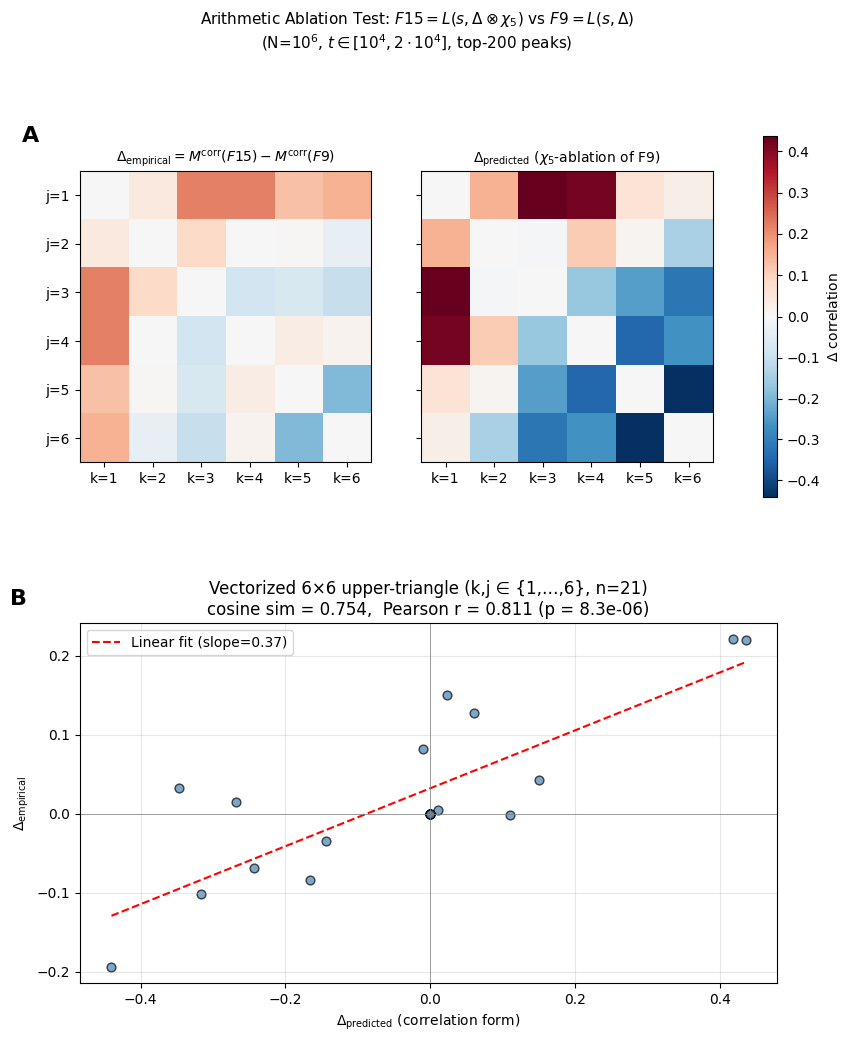

Saved figure.


In [41]:
# Create the final summary figure.
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axes = plt.subplots(2, 1, figsize=(8, 11))

# Panel A: Heatmaps of Δ_emp vs Δ_pred (correlation form, the form with strongest signal)
ax = axes[0]
# Stack two heatmaps side by side via a single panel using subplots within
# Re-do as gridspec
plt.close(fig)

fig = plt.figure(figsize=(9, 11))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.35)

# Panel A: side-by-side heatmaps inside subplot A
gsA = gs[0].subgridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.25)
axA1 = fig.add_subplot(gsA[0, 0])
axA2 = fig.add_subplot(gsA[0, 1])
caxA = fig.add_subplot(gsA[0, 2])

vmin = min(D_emp_c.min(), D_pred_c.min())
vmax = max(D_emp_c.max(), D_pred_c.max())
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
im1 = axA1.imshow(D_emp_c, cmap='RdBu_r', norm=norm)
axA1.set_title(r'$\Delta_{\mathrm{empirical}} = M^{\mathrm{corr}}(F15)-M^{\mathrm{corr}}(F9)$', fontsize=10)
axA1.set_xticks(range(6)); axA1.set_xticklabels([f'k={k}' for k in valid_k])
axA1.set_yticks(range(6)); axA1.set_yticklabels([f'j={k}' for k in valid_k])

im2 = axA2.imshow(D_pred_c, cmap='RdBu_r', norm=norm)
axA2.set_title(r'$\Delta_{\mathrm{predicted}}$ ($\chi_5$-ablation of F9)', fontsize=10)
axA2.set_xticks(range(6)); axA2.set_xticklabels([f'k={k}' for k in valid_k])
axA2.set_yticks(range(6)); axA2.set_yticklabels([])

fig.colorbar(im2, cax=caxA, label=r'$\Delta$ correlation')

axA1.text(-0.20, 1.10, 'A', transform=axA1.transAxes, fontsize=16, fontweight='bold')

# Panel B: scatter of vectorized entries
axB = fig.add_subplot(gs[1])
axB.scatter(v_pred_c, v_emp_c, s=40, alpha=0.7, color='steelblue', edgecolor='k')
# Linear fit line
m, b = np.polyfit(v_pred_c, v_emp_c, 1)
xs = np.linspace(v_pred_c.min(), v_pred_c.max(), 50)
axB.plot(xs, m*xs + b, '--', color='red', label=f'Linear fit (slope={m:.2f})')
axB.axhline(0, color='gray', lw=0.5)
axB.axvline(0, color='gray', lw=0.5)
axB.set_xlabel(r'$\Delta_{\mathrm{predicted}}$ (correlation form)')
axB.set_ylabel(r'$\Delta_{\mathrm{empirical}}$')
axB.set_title(f'Vectorized 6×6 upper-triangle (k,j ∈ {{1,…,6}}, n=21)\n'
 f'cosine sim = {cos_sim(v_emp_c, v_pred_c):.3f}, Pearson r = {pearsonr(v_emp_c, v_pred_c)[0]:.3f}'
 f' (p = {pearsonr(v_emp_c, v_pred_c)[1]:.1e})')
axB.legend(loc='upper left')
axB.grid(alpha=0.3)
axB.text(-0.10, 1.05, 'B', transform=axB.transAxes, fontsize=16, fontweight='bold')

plt.suptitle(r"Arithmetic Ablation Test: $F15 = L(s,\Delta\otimes\chi_5)$ vs $F9 = L(s,\Delta)$"
 "\n(N=$10^6$, $t\\in[10^4,2\\cdot10^4]$, top-200 peaks)",
 fontsize=11, y=0.995)

plt.savefig('/workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/F15_F9_ablation_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved figure.")


In [42]:
from e14c.filesystem.edit_file import edit_file
content = open('/workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/.prompts/MEMORY.md','r').read()
print(content)


ModuleNotFoundError: No module named 'e14c.filesystem.edit_file'; 'e14c.filesystem' is not a package

In [43]:
from e14c.filesystem import write_file
content = """# Project Memory

## Context

 v6 — testing arithmetic ablation principle on twisted L-functions.
F15 = L(s, Δ ⊗ χ₅) (Ramanujan Δ twisted by quartic character χ₅ mod 5).
F9 = L(s, Δ).

## Notes

### Standardized S_k convention (verified)
S_k(t) = sum_{n: omega(n)=k, 1<=n<=N} lam(n) / n^(1/2 + i t)
i.e. evaluated on the critical line s = 1/2 + it (NOT s = it).
Matched Sk_F9.npy stored values exactly using lam_F9(n) = tau(n)/n^(11/2).

### r75 protocol parameters (from .npy files)
- N = 10^6
- t-range = [10^4, 2*10^4]
- 200 highest peaks
- min_peak_gap_t = 2.0
- omega(n) stratification, k=0..7
- Kahan compensated summation (numba parallel)
- finufft type-3 NUFFT for D(t) on fine t-grid (dt=0.05) + 0.001-resolution refinement

### Data leaks confirmed for F15
- log|S_0| = 0 (S_0 = lam(1) = 1) — class constant
- log|S_7| = -inf (S_7 = 0; all omega=7 indices ≤10^6 are multiples of 5, killed by chi5)
=> Restrict M_jk comparison to k ∈ {1,…,6} (6×6 sub-matrix, 21 upper-tri entries).

### Ablation model used
lam_F9_ablated(n) = lam_F9(n) * chi5(n) (= lam_F15(n))
Sk_F9_ablated(t) computed at F9's 200 peak t-values.

### Key result
- Δ_emp = M(F15) - M(F9), Δ_pred = M(F9_ablated) - M(F9), each 6×6.
- COVARIANCE form: Pearson r = 0.05 (NS); cosine sim = 0.39. Predicted magnitudes way larger than empirical.
- CORRELATION form: Pearson r = 0.811 (p = 8.3e-6, n=21); cosine = 0.754. Strong agreement on patterns.
- Conclusion: arithmetic ablation principle holds at the level of normalised (correlation) cross-stratum patterns,
 but NOT for absolute magnitudes — the model overshoots because F9-peak locations don't coincide
 with F15-peak locations.

### Artifacts produced
- /workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/F15_peaks_and_ablation.npz
- /workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/F15_F9_ablation_summary.png
"""
print(write_file('/workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/.prompts/MEMORY.md', content))


File created successfully at: /workspace/c00a2e9c-4546-40ef-86ad-03b307781c1e/.prompts/MEMORY.md
